In [2]:
# %% [markdown]
# # CMAPSS FD001 – LSTM with Keras
# 
# - Loads CMAPSS via step1_ml_pipeline
# - Builds sliding windows per engine
# - Trains an LSTM for RUL regression
# - Reports MAE / RMSE / R²

# %%
!pip install tensorflow --quiet

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from step1_ml_pipeline import load_cmapss_data, data_processing


In [3]:
# %% 
# Load and standardize CMAPSS using your existing pipeline
dataname = "FD001"

train_df_raw, test_df_raw = load_cmapss_data(dataname)
train_std, test_std, scaler = data_processing(train_df_raw, test_df_raw)

print(train_std.head())
print(test_std.head())

print("Columns:", list(train_std.columns))


   engine_id  cycle  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  \
0          1      1       0.0 -1.214815 -0.049261 -0.610086       0.0   
1          1      2       0.0 -0.725926  0.211823 -0.401804       0.0   
2          1      3       0.0 -0.429630 -0.259852 -0.314883       0.0   
3          1      4       0.0 -0.429630 -0.900246 -0.505945       0.0   
4          1      5       0.0 -0.400000 -0.892857 -0.149241       0.0   

   sensor_6  sensor_7  sensor_8  ...  sensor_13  sensor_14  sensor_15  \
0       0.0  0.766667 -0.333333  ...       -0.7  -0.127448  -0.382643   
1       0.0  0.258333 -0.555556  ...       -0.2  -0.600730  -0.140039   
2       0.0  0.683333 -0.111111  ...       -0.6  -0.485231  -0.416174   
3       0.0  0.841667  0.222222  ...       -0.1  -0.445403  -1.394477   
4       0.0  0.466667 -0.333333  ...       -0.5  -0.447395  -0.187377   

   sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  RUL  
0        0.0       -0.5        0.0        0.0  

In [4]:
# %%
# Columns to use as features (drop id / target)
exclude = ["engine_id", "cycle", "RUL"]
feature_cols = [c for c in train_std.columns if c not in exclude]
n_features = len(feature_cols)
print("Num features:", n_features)

# Split engines: some engines for training, some for validation
val_frac = 0.15
rng = np.random.default_rng(seed=42)

eng_ids = train_std["engine_id"].unique()
rng.shuffle(eng_ids)

cut = int((1.0 - val_frac) * len(eng_ids))
val_ids = set(eng_ids[cut:])

mask_val = train_std["engine_id"].isin(val_ids)

train_df = train_std[~mask_val].copy()
val_df   = train_std[mask_val].copy()
test_df  = test_std.copy()

print(f"# train engines: {train_df['engine_id'].nunique()}")
print(f"#  val  engines: {val_df['engine_id'].nunique()}")
print(f"# test engines:  {test_df['engine_id'].nunique()}")


Num features: 21
# train engines: 85
#  val  engines: 15
# test engines:  100


In [5]:
# %% 
def make_windows(df, feature_cols, window_size):
    """
    df: DataFrame with engine_id, cycle, RUL, and sensor features
    returns:
      X: (N, window_size, n_features)
      y: (N,)
    """
    X_list = []
    y_list = []

    for eng_id, eng_df in df.groupby("engine_id"):
        eng_df = eng_df.sort_values("cycle")
        feats = eng_df[feature_cols].to_numpy()
        rul   = eng_df["RUL"].to_numpy()

        if len(eng_df) < window_size:
            continue  # skip very short engines (rare)

        for start in range(0, len(eng_df) - window_size + 1):
            end = start + window_size
            X_seq = feats[start:end, :]                 # (window_size, n_features)
            y_val = rul[end - 1]                        # RUL at last time step
            X_list.append(X_seq)
            y_list.append(y_val)

    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype=float)
    return X, y

window_size = 120
print("Making sliding windows with window_size =", window_size)

X_tr, y_tr = make_windows(train_df, feature_cols, window_size)
X_val, y_val = make_windows(val_df, feature_cols, window_size)
X_te, y_te = make_windows(test_df, feature_cols, window_size)

print("X_tr:", X_tr.shape, "y_tr:", y_tr.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_te:", X_te.shape, "y_te:", y_te.shape)


Making sliding windows with window_size = 120
X_tr: (7452, 120, 21) y_tr: (7452,)
X_val: (1279, 120, 21) y_val: (1279,)
X_te: (2840, 120, 21) y_te: (2840,)


In [6]:
#  LSTM without attention
import tensorflow as tf
from tensorflow import keras

input_shape = (window_size, n_features)
inputs = keras.Input(shape=input_shape)

# 1) Stacked LSTM
x = keras.layers.LSTM(64, return_sequences=True)(inputs)   # keep sequence for first layer
x = keras.layers.LSTM(32, return_sequences=False)(x)       # last time step only -> (batch, 32)     

# 2) Dense + output
h = keras.layers.Dense(64, activation="relu")(x)
outputs = keras.layers.Dense(1)(h)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 120, 21)]         0         
                                                                 
 lstm (LSTM)                 (None, 120, 64)           22016     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 64)                2112      
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 36609 (143.00 KB)
Trainable params: 36609 (143.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
# %%  (new cell – after model = keras.Model(...) )
import tensorflow as tf
from tensorflow import keras

def nasa_score_metric(y_true, y_pred):
    # y_true, y_pred shape: (batch, 1)
    d = y_pred - y_true
    s = tf.where(
        d < 0.0,
        tf.exp(-d / 13.0) - 1.0,   # early predictions (pessimistic)
        tf.exp(d / 10.0) - 1.0     # late predictions (over-optimistic)
    )
    # mean per batch, good for logging
    return tf.reduce_mean(s)


In [8]:

loss_fn = keras.losses.Huber(delta=20.0)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE"),
        nasa_score_metric      # <- our custom metric
    ]
)


early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)


In [9]:
# %%
batch_size = 256
epochs = 80

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop, reduce_lr],
    verbose=2,
)


Epoch 1/80


30/30 - 5s - loss: 902.9792 - MAE: 54.1385 - nasa_score_metric: 280393.0000 - val_loss: 775.6119 - val_MAE: 47.4802 - val_nasa_score_metric: 19763.3848 - lr: 0.0010 - 5s/epoch - 151ms/step
Epoch 2/80
30/30 - 2s - loss: 763.9646 - MAE: 46.7809 - nasa_score_metric: 138339.8281 - val_loss: 620.4849 - val_MAE: 39.4635 - val_nasa_score_metric: 8546.1621 - lr: 0.0010 - 2s/epoch - 72ms/step
Epoch 3/80
30/30 - 2s - loss: 625.6570 - MAE: 39.8339 - nasa_score_metric: 54271.0508 - val_loss: 513.0174 - val_MAE: 34.1116 - val_nasa_score_metric: 3561.5403 - lr: 0.0010 - 2s/epoch - 73ms/step
Epoch 4/80
30/30 - 2s - loss: 539.7717 - MAE: 35.6174 - nasa_score_metric: 25096.7500 - val_loss: 466.4834 - val_MAE: 31.9104 - val_nasa_score_metric: 1669.0754 - lr: 0.0010 - 2s/epoch - 74ms/step
Epoch 5/80
30/30 - 2s - loss: 506.3745 - MAE: 34.0240 - nasa_score_metric: 12821.3662 - val_loss: 457.5759 - val_MAE: 31.5848 - val_nasa_score_metric: 1058.9695 - lr: 0.0010 - 2s/epoch - 70ms/step
Epoch 6/8

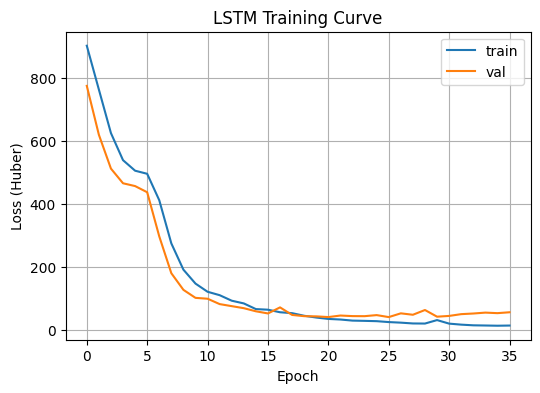

In [10]:
# %%
hist = history.history

plt.figure(figsize=(6,4))
plt.plot(hist["loss"], label="train")
plt.plot(hist["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss (Huber)")
plt.title("LSTM Training Curve")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
# %%
y_pred = model.predict(X_te).ravel()

mae  = float(np.mean(np.abs(y_te - y_pred)))
rmse = float(np.sqrt(np.mean((y_te - y_pred)**2)))
ss_res = float(np.sum((y_te - y_pred)**2))
ss_tot = float(np.sum((y_te - np.mean(y_te))**2))
r2 = 1.0 - ss_res / ss_tot

def nasa_score_numpy(y_true, y_pred):
    d = y_pred - y_true

    s = np.where(
        d >= 0,
        np.exp(d / 13.0) - 1.0,      # early prediction, lighter penalty
        np.exp(-d / 10.0) - 1.0      # late prediction, heavier penalty
    )

    return float(np.sum(s))


nasa = nasa_score_numpy(y_te, y_pred)

print(f"Test MAE   = {mae:.2f}")
print(f"Test RMSE  = {rmse:.2f}")
print(f"Test R²    = {r2:.3f}")
print(f"NASA score = {nasa:.2f}")


89/89 [==============================] - 1s 10ms/step
Test MAE   = 15.20
Test RMSE  = 22.89
Test R²    = 0.757
NASA score = 142802.23


In [14]:
import pandas as pd

cycle_idx = 1      # as above
engine_idx = 0     # if you stored engine_id, otherwise skip

test_cycles = X_te[:, -1, cycle_idx]
test_engines = X_te[:, -1, engine_idx]  # optional

df_out = pd.DataFrame({
    "engine_id": test_engines,   # drop if you don't have it
    "cycle": test_cycles,
    "true_RUL": y_te,
    "pred_RUL_lstm": y_pred,
    "pred_RUL_weibull": y_pred_weibull,   # optional baseline
})

df_out.to_csv("rul_predictions_for_optimization.csv", index=False)
print("Saved rul_predictions_for_optimization.csv")


Saved rul_predictions_for_optimization.csv


In [ ]:
import numpy as np
from scipy.stats import weibull_min
from scipy.integrate import quad

# 1) Get failure cycles from df_train
failure_times = train_df.groupby("engine_id")["cycle"].max().values

# 2) Fit Weibull(k, lam)
k, loc, lam = weibull_min.fit(failure_times, floc=0)
print("k =", k, "  λ =", lam)

# 3) Weibull mean residual life
def weibull_RUL(cycle, k, lam):
    t = float(cycle)
    S = lambda u: np.exp(- (u / lam)**k)
    S_t = S(t)
    if S_t < 1e-12:
        return 0.0
    num, _ = quad(S, t, t + 5000)
    return num / S_t

# 4) Extract cycle from your windows (assuming cycle is feature 0)
test_cycles = np.array([window[-1, 0] for window in X_te])

# 5) Predict Weibull RUL
y_pred_weibull = np.array([
    weibull_RUL(c, k, lam) for c in test_cycles
])

# 6) Score
nasa_weibull = nasa_score_numpy(y_te, y_pred_weibull)
print("Weibull NASA =", nasa_weibull)


k = 4.358267486977011   λ = 225.58064751777857
Weibull NASA = 690717322.2447143
